# This is for outpainting

In [32]:
n = 2
idx = (0, 0)

def update(idx, move):
    x, y = idx
    if move == 0:
        x += 0.5
    if move == 1:
        y += 0.5
    if move == 2:
        x -= 0.5
    if move == 3:
        y -= 0.5

    return (x, y)

def outpaint_scheduler(idx, n):
    for i in range(1,n+1,1):
        print("i",i)
        j = 0
        if i % 2 == 1:
            idx = update(idx, 0)
            #outpaint blocks (0,1) with idx -=(-0.5,0) 's (0,1)
            for j in range(i):
                idx = update(idx, 1)
                #if j == 0 outpaint 2 blocks else 1 blocks
            for j in range(i):
                idx = update(idx, 2)
        else:
      
            idx = update(idx, 2)
       
            for j in range(i):
                idx = update(idx, 3)
            for j in range(i):
                idx = update(idx, 0)
        print(idx)
    return idx


idx = outpaint_scheduler(idx, 3)
    # print(n," Final idx:", idx)


i 1
(0.0, 0.5)
i 2
(0.5, -0.5)
i 3
(-0.5, 1.0)


In [33]:
from octree_diff.diffusion.util_sample_stuff import *
from octree_diff.octree.util_octree_stuff import *
from octree_diff.octree.util_dualoctree import *

Load NNs

In [27]:
from octree_diff.models.semantic.graph_sem_vae import GraphVAE
DEPTH_STOP = 6
LATENT_DIM = 8
FULL_DEPTH = 3
vae = GraphVAE(
    depth=6,
    channel_in=32,     
    nout=2,
    full_depth=FULL_DEPTH,
    depth_stop=DEPTH_STOP ,
    depth_out=6,
    latent_dim=LATENT_DIM,  
    num_classes=21,# latent dimension
    resblk_num=1,
    
).cuda()

vae.load_state_dict(torch.load("/home/brendan/SemCityOcto/vae_fdepth6_ldim8_8.pt"),vae.parameters())

vae.eval() 

import torch
from octree_diff.models.semantic.dual_octree import DualOctree
from octree_diff.models.semantic.graph_unet_hr import UNet3DModel

# === 1. Hyperparams ===
in_channels = LATENT_DIM        # dimension of latent z
model_channels = 64

lr_model_channels = 128
out_channels = LATENT_DIM      # same as input if predicting noise
image_size = 16
depth = DEPTH_STOP
full_depth = FULL_DEPTH
channel_mult = [2,4]
num_res_blocks = [2, 2, 2]



# === 4. Init and forward model ===
unet_model = UNet3DModel(
    image_size=image_size,
    input_depth=depth,
    full_depth=full_depth,
    in_channels=in_channels,
    model_channels=model_channels,
    lr_model_channels=lr_model_channels,
    out_channels=out_channels,
    num_res_blocks=num_res_blocks,
    dropout=0.1,
    channel_mult=channel_mult,
    use_checkpoint=False,
).cuda()

unet_model.load_state_dict(torch.load("Model_is_good_8_6.pt"),unet_model.parameters())
unet_model.eval()

from octree_diff.models.outdoor.graph_unet_lr import UNet3DModel
batch_size = 1
in_channels = 8
spatial_size = 16
full_depth = 4  # dummy value, used only in forward_as_middle
model_channels = 32
out_channels = 8



structure_model = UNet3DModel(
    full_depth=full_depth,
    in_split_channels=in_channels,
    model_channels=model_channels,
    out_split_channels=out_channels,
    attention_resolutions=[2, 4, 8],  # example downsample scales
    dims=3,  # 3D model
    num_heads=4,
).cuda()

structure_model.load_state_dict(torch.load("structure_model.pt"),structure_model.parameters())
structure_model.eval()

/tmp/ipykernel_102083/603582172.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vae.load_state_dict(torch.load("/home/brendan/SemCityOcto/vae_fdepth6_ldim8_8.pt"),vae.p

UNet3DModel(
  (time_pos_emb): LearnedSinusoidalPosEmb()
  (time_emb): Sequential(
    (0): Linear(in_features=33, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (input_emb): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  (downs): ModuleList(
    (0): ModuleList(
      (0): ResnetBlock(
        (time_mlp): Sequential(
          (0): SiLU()
          (1): Linear(in_features=128, out_features=32, bias=True)
        )
        (block1): Sequential(
          (0): GroupNorm32(32, 32, eps=1e-05, affine=True)
          (1): SiLU()
          (2): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        )
        (block2): Sequential(
          (0): GroupNorm32(32, 32, eps=1e-05, affine=True)
          (1): SiLU()
          (2): Dropout(p=0, inplace=False)
          (3): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        )
        (res_conv): 

In [28]:
def voxel_to_patch(vox, patch_size=8):
    """
    Input:
        vox: [B, H, W, D] = [B, 128, 128, 32]
    Output:
        [B, H//p, W//p, D, p, p] = [B, 32, 32, 32, 4, 4]
    """
    B, H, W, D = vox.shape
    P = patch_size
    assert H % P == 0 and W % P == 0, "Height/Width must be divisible by patch size"

    vox = vox.view(B, H//P, P, W//P, P, D)               # [B, 32, 4, 32, 4, D]
    vox = vox.permute(0, 1, 3, 5, 2, 4)                  # [B, 32, 32, D, 4, 4]
    return vox  # [B, 32, 32, D, 4, 4]
def patch_to_voxel(patches):
    """
    Input:
        patches: [B, 32, 32, 32, 4, 4]
    Output:
        [B, 128, 128, 32]
    """
    B, H, W, D, p1, p2 = patches.shape
    assert p1 == p2, "patch must be square"

    vox = patches.permute(0, 1, 4, 2, 5, 3)              # [B, 32, 4, 32, 4, D]
    vox = vox.reshape(B, H * p1, W * p2, D)              # [B, 128, 128, D]
    return vox
def get_non_empty_mask(vox, patch_size=8):
    """
    Input:
        vox: [128, 128, 32]
    Output:
        mask: [32, 32, 32] (bool), True if corresponding 4x4 patch contains nonzero
    """
    H, W, D = vox.shape
    P = patch_size
    assert H % P == 0 and W % P == 0

    # reshape to group patches
    vox_reshaped = vox.view(H//P, P, W//P, P, D)           # [32, 4, 32, 4, 32]
    vox_reshaped = vox_reshaped.permute(0, 2, 4, 1, 3)     # [32, 32, 32, 4, 4]

    # check if any voxel in each patch is non-zero
    mask = (vox_reshaped != 0).any(dim=(-1, -2))           # [32, 32, 32]
    return mask


In [29]:
import os
import torch

# Make sure the output directory exists
output_dir = './split_outputs'
os.makedirs(output_dir, exist_ok=True)
OFFSET = 0  # you must define this based on your needs
cnt = 0
from octree_diff.data.kitti.velodyne_to_voxel import velodene_to_voxel


gt = velodene_to_voxel( "/home/brendan/SemCityOcto/dataset/", "00", "000202")
real_mask = gt != 0
vox = torch.tensor(real_mask).unsqueeze(0)


# vox[invalid == 1] = 0
# vox[vox == 255] = 0

patch = voxel_to_patch(vox, 4)
vox_recon = patch_to_voxel(patch)

non_empty_mask = get_non_empty_mask(vox[0], 4)
non_empty_mask_padded = torch.zeros((64, 64, 64))

non_empty_mask_padded[:, :, OFFSET:OFFSET + 32] = non_empty_mask

points = voxel_grid_to_points(non_empty_mask_padded)
octree = points2octree(points, depth=6, full_depth=3)

split = octree2split_small(octree, 4)
split_cut = split[:, :, :, :, 0:8]  # shape: [C, D, H, W, 8]

split_cut[split_cut == -1] = 0
# split_cut[split_cut == 1] = 1
# Save to file with counter
save_path = os.path.join(output_dir, f"split_cut_{cnt:08d}.pt")
torch.save(split_cut, save_path)

#     cnt += 1

Loading data for sequence 00, scan 000202...


In [30]:
visualize_kitti_instance(torch.tensor(gt).cuda())
visualize_structure(vox_recon[0])

IndexError: index 2 is out of bounds for axis 1 with size 2

In [31]:


z_T = torch.randn(1, 8, 16, 16, 8).to('cuda')  # starting noise
sample = ddim_sample_structure_logsnr_cosine(z_T, structure_model,   S=50)
tada = sample.clone()
sample[sample>0] = 1
sample[sample<=0] = -1
split_recon = torch.ones((1,8,16,16,16))*(-1)
split_recon[:,:,:,:,0:8] = sample
octree_recon = split2octree_small(split_recon, 6, 4)
octree_in = octree_recon
octree_out = vae.create_child_octree(octree_in).cuda()
doctree = DualOctree(octree_out)
doctree.post_processing_for_docnn()
print(doctree.total_num)
z_rand = torch.randn(doctree.total_num, LATENT_DIM)
z_T = z_rand.cuda()


z_sampled = ddim_sample_logsnr_cosine(
    z_T=z_T,
    model=unet_model,
    doctree=doctree,
    S=50
    
)


output = vae.decode_code(z_sampled.cuda(), doctree, update_octree=False, pos=None)
recon_voxel = reconstruct_voxel_from_patch(output['sem_voxs'], octree_recon.cuda(), depth=6, shape=(1, 256, 256, 32), patch_size=4)

gt[gt != 0] = 20
# visualize_kitti_instance(torch.tensor(gt).cuda())
visualize_kitti_instance(recon_voxel[0])

42141


In [24]:
vox = recon_voxel[0]
intersection = (vox.detach().cpu() != 0) & (gt != 0)
print(intersection.sum() /  (gt != 0).sum())
vox[gt == 20] = 20
visualize_kitti_instance(vox)

/tmp/ipykernel_102083/1735446093.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  intersection = (vox.detach().cpu() != 0) & (gt != 0)


tensor(0.0534)


In [4]:
tada

NameError: name 'tada' is not defined

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline
data = tada.flatten().detach().cpu().numpy()
# data = data[data>0]
print(data.shape)
plt.close()
fig, ax = plt.subplots(1, 1)
plt.hist(data)
plt.show()

NameError: name 'tada' is not defined

In [6]:
data.shape

NameError: name 'data' is not defined

In [27]:
data[0:10]

array([0.02436261, 0.95627093, 1.0846627 , 1.5964803 , 1.8912055 ,
       1.3999596 , 1.8753861 , 2.5111907 , 0.22736177, 1.5630859 ],
      dtype=float32)

In [33]:
import numpy as np
from sklearn.mixture import GaussianMixture
X = data.reshape(-1, 1)

# Fit a GMM with 2 components
gmm = GaussianMixture(n_components=2, random_state=0)
gmm.fit(X)

# Extract parameters
means = gmm.means_.flatten()                   # mean of each Gaussian
stds = np.sqrt(gmm.covariances_).flatten()     # std dev of each Gaussian
weights = gmm.weights_.flatten()               # mixing coefficients

print("Means:", means)
print("Stds:", stds)
print("Weights:", weights)

Means: [-1.0062909  0.9995757]
Stds: [0.1185278 1.8374355]
Weights: [0.5625725 0.4374275]


Means: [-1.00409706  0.98676002]
Stds: [0.09908772 0.49643325]
Weights: [0.94998177 0.05001823]


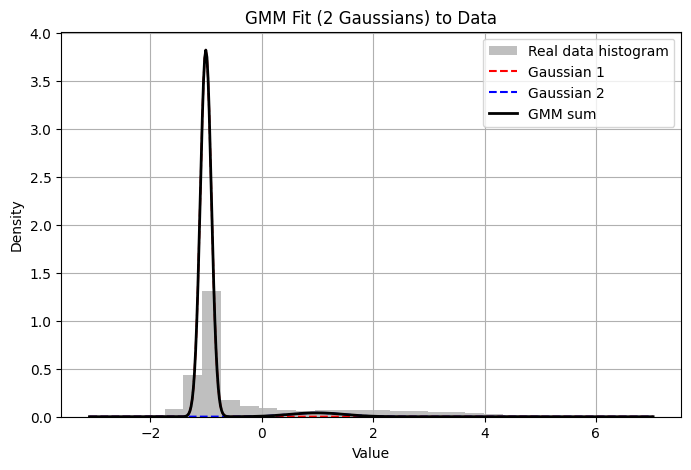

In [39]:

# X = data.reshape(-1, 1)
X = np.append(np.random.normal(-1, 0.1, 950), np.random.normal(1, 0.5, 50)).reshape(-1, 1)

# === Fit 2-Gaussian GMM ===
gmm = GaussianMixture(n_components=2, random_state=0)
gmm.fit(X)

means = gmm.means_.flatten()
stds = np.sqrt(gmm.covariances_).flatten()
weights = gmm.weights_.flatten()

print("Means:", means)
print("Stds:", stds)
print("Weights:", weights)

# === Prepare x range for plotting ===
x = np.linspace(min(data), max(data), 500)

# PDF of each Gaussian
def gaussian_pdf(x, mean, std):
    return 1/(std * np.sqrt(2*np.pi)) * np.exp(-0.5 * ((x - mean)/std)**2)

# Compute PDFs
pdf1 = weights[0] * gaussian_pdf(x, means[0], stds[0])
pdf2 = weights[1] * gaussian_pdf(x, means[1], stds[1])
pdf_sum = pdf1 + pdf2

# === Plot ===
plt.figure(figsize=(8, 5))
# Histogram of real data (normalized to form PDF)
plt.hist(data, bins=30, density=True, alpha=0.5, color='gray', label='Real data histogram')

# GMM components
plt.plot(x, pdf1, 'r--', label='Gaussian 1')
plt.plot(x, pdf2, 'b--', label='Gaussian 2')

# GMM total
plt.plot(x, pdf_sum, 'k-', linewidth=2, label='GMM sum')

plt.xlabel('Value')
plt.ylabel('Density')
plt.title('GMM Fit (2 Gaussians) to Data')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
visualize_kitti_instance(torch.Tensor(gt).cuda())

VoxelGrid with 12864 voxels.

In [8]:
import numpy as np
from numba import njit, prange

# occupancy: int8 array with values {-1: unknown, 0: free, 1: occupied}
# grid shape: (H, W, D) e.g., (256, 256, 32)
# origin: (ox, oy, oz) integer voxel indices
# hits: int32 array of shape [N, 3], each row (x, y, z) is an occupied voxel to backtrace from.

@njit(cache=True)
def _dda_trace_mark_free(occ, ox, oy, oz, hx, hy, hz):
    """
    3D DDA from hit voxel (hx,hy,hz) toward origin (ox,oy,oz).
    Turns any -1 encountered into 0. Stops when reaching a 0 (already free) or origin.
    """
    x, y, z = hx, hy, hz
    if x == ox and y == oy and z == oz:
        return

    # Direction (from hit -> origin), step per axis
    dx = ox - x
    dy = oy - y
    dz = oz - z

    step_x = 0 if dx == 0 else (1 if dx > 0 else -1)
    step_y = 0 if dy == 0 else (1 if dy > 0 else -1)
    step_z = 0 if dz == 0 else (1 if dz > 0 else -1)

    # Work in "cell-center coordinates"
    # Current point at center: (x+0.5, y+0.5, z+0.5)
    # Ray direction as floats:
    rdx = float(dx)
    rdy = float(dy)
    rdz = float(dz)

    # Avoid division by zero
    inv_rdx = 1.0 / abs(rdx) if dx != 0 else 1e30
    inv_rdy = 1.0 / abs(rdy) if dy != 0 else 1e30
    inv_rdz = 1.0 / abs(rdz) if dz != 0 else 1e30

    # Distance (in param t) to the first grid boundary in each axis
    # From center to the boundary we’ll cross first, measured along ray paramization.
    # Center offset to next boundary is 0.5 toward the step direction.
    tMaxX = 0.5 * inv_rdx if dx != 0 else 1e30
    tMaxY = 0.5 * inv_rdy if dy != 0 else 1e30
    tMaxZ = 0.5 * inv_rdz if dz != 0 else 1e30

    # Delta t between crossings in each axis (how far between voxel boundaries)
    tDeltaX = 1.0 * inv_rdx
    tDeltaY = 1.0 * inv_rdy
    tDeltaZ = 1.0 * inv_rdz

    H, W, D = occ.shape

    # March until we reach origin
    while not (x == ox and y == oy and z == oz):
        # Mark unknown as free
        if 0 <= x < H and 0 <= y < W and 0 <= z < D:
            if occ[x, y, z] == -1:
                occ[x, y, z] = 0
            elif occ[x, y, z] == 0:
                # already free; remaining to origin must have been carved already
                break
        else:
            # Out of bounds; bail
            break

        # Advance in the axis with smallest next boundary distance
        if tMaxX <= tMaxY and tMaxX <= tMaxZ:
            x += step_x
            tMaxX += tDeltaX
        elif tMaxY <= tMaxX and tMaxY <= tMaxZ:
            y += step_y
            tMaxY += tDeltaY
        else:
            z += step_z
            tMaxZ += tDeltaZ

    # Optionally: we do not change the hit or origin cells themselves here.
    # If you want the origin to be forced free:
    # if 0 <= ox < H and 0 <= oy < W and 0 <= oz < D and occ[ox,oy,oz] == -1:
    #     occ[ox,oy,oz] = 0


@njit(parallel=True, cache=True)
def carve_free_from_hits(occ, origin, hits_sorted):
    ox, oy, oz = origin
    n = hits_sorted.shape[0]
    for i in prange(n):
        hx, hy, hz = hits_sorted[i, 0], hits_sorted[i, 1], hits_sorted[i, 2]
        _dda_trace_mark_free(occ, ox, oy, oz, hx, hy, hz)


def reverse_ray_trace(occupancy, origin, hits):
    """
    occupancy: np.int8 [H,W,D], values in {-1,0,1}
    origin: (ox,oy,oz) ints
    hits: np.int32 [N,3], indices of occupied voxels to backtrace from (these should be 1s in occupancy)
    Returns: occupancy modified in-place.
    """
    # Sort hits far->near to maximize early termination
    ox, oy, oz = origin
    if hits.shape[0] == 0:
        return occupancy
    d2 = (hits[:,0]-ox)**2 + (hits[:,1]-oy)**2 + (hits[:,2]-oz)**2
    order = np.argsort(-d2)  # descending distance
    hits_sorted = hits[order].astype(np.int32)
    carve_free_from_hits(occupancy, np.array(origin, dtype=np.int32), hits_sorted)
    return occupancy
from numba import njit, prange
import numpy as np
import torch

@njit(cache=True)
def _fill_between_ones_1d(arr):
    n = arr.shape[0]
    i = 0
    while i < n:
        while i < n and arr[i] != 1:
            i += 1
        if i >= n:
            break
        j = i + 1
        while j < n and arr[j] != 1:
            j += 1
        if j < n:
            for k in range(i+1, j):
                if arr[k] == 0:   # only fill 0s → 1; leave -1 as unknown
                    arr[k] = 1
        i = j

@njit(parallel=True, cache=True)
def ground_convex_fill_levels(occ, z_levels):
    """
    occ: int8 [H,W,D]
    z_levels: int32 [L] (1D!) of slice indices to fill (e.g., [0,1])
    """
    H, W, D = occ.shape
    L = z_levels.shape[0]
    for zi in range(L):
        z = z_levels[zi]               # scalar int
        if z < 0 or z >= D:
            continue

        # along X for each Y
        for y in prange(W):
            line = occ[:, y, z]        # shape H
            _fill_between_ones_1d(line)

        # along Y for each X
        for x in prange(H):
            line = occ[x, :, z]        # shape W
            _fill_between_ones_1d(line)

def reverse_ray_trace_with_ground_fill(occ, origin, hits, z_levels=(0,1)):
    """
    occ: np.int8 [H,W,D], mutated in place
    origin: (ox,oy,oz)
    hits: np.int32 [N,3]
    z_levels: iterable of ints (e.g., (0,1))
    """
    # ---- your existing reverse ray trace ----
    if hits.size > 0:
        occ[hits[:,0], hits[:,1], hits[:,2]] = 1
    occ = reverse_ray_trace(occ, origin, hits)

    # ---- enforce 1D int32 z_levels for numba ----
    z_levels = np.array(tuple(int(z) for z in z_levels), dtype=np.int32)
    ground_convex_fill_levels(occ, z_levels)
    return occ

In [9]:
H, W, D = 256, 256, 32
occ = np.full((H, W, D), -1, dtype=np.int8)
origin = (0, 128, 9)

gt[gt != 0] = 20
hits = np.argwhere(gt == 20).astype(np.int32)
if hits.size > 0:
    occ[hits[:,0], hits[:,1], hits[:,2]] = 1

# ✅ Pass z_levels=(0,1) here, NOT hits
occ = reverse_ray_trace_with_ground_fill(occ, origin, hits, z_levels=(0,1,2,3))

# to torch
occupancy = torch.tensor(occ, device='cuda')


In [10]:
occupancy_vis = occupancy.clone()
occupancy_vis[occupancy_vis == -1] = 0
visualize_kitti_instance(torch.Tensor(occupancy_vis).cuda())

In [13]:
occupancy_vis[occupancy_vis == 1] = 20
(occupancy_vis != gt).sum()

AttributeError: 'bool' object has no attribute 'sum'

In [11]:
mask = torch.tensor((occupancy != -1)).cuda() 

/tmp/ipykernel_82247/819968393.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor((occupancy != -1)).cuda()


In [12]:
visualize_kitti_instance(mask)

In [13]:



@torch.no_grad()
def ddim_sample_structure_logsnr_cosine_inpaint(z_T, z_gt,model, mask, S=50, jump_n_sample = 10,predict_mode="x0"):
    """
    DDIM sampling using logSNR cosine schedule and x₀ prediction.

    Args:
        z_T (torch.Tensor): Starting noise [B, C, H, W, D]
        model (nn.Module): The trained diffusion model
        doctree: Optional structure for conditioning (can be None)
        S (int): Number of inference steps
        predict_mode (str): Must be "x0" for now
    Returns:
        z_t: final denoised sample [B, C, H, W, D]
    """
    assert predict_mode == "x0", "Only x0 mode is supported for now."

    # === Setup DDIM timestep schedule ===
    t_steps = torch.linspace(1., 0., S + 1, device=z_T.device)  # [S+1]
    t_pairs = list(zip(t_steps[:-1], t_steps[1:]))              # [(t_s, t_s-1)]

    z_t = z_T
 
    
    for t, t_next in t_pairs:
        # Shape [B], values = current time
        for j in range(jump_n_sample): 
            t_tensor = torch.full((z_t.shape[0],), t, device=z_t.device)
            t_next_tensor = torch.full((z_t.shape[0],), t_next, device=z_t.device)

            logsnr_t     = alpha_cosine_log_snr(t_tensor)
            logsnr_next = alpha_cosine_log_snr(t_next_tensor)

            alpha_t, sigma_t = log_snr_to_alpha_sigma(logsnr_t)
            alpha_next, sigma_next = log_snr_to_alpha_sigma(logsnr_next)

            # Reshape for broadcasting: [B, 1, 1, 1, 1]
            alpha_t     = alpha_t[:, None, None, None, None]
            sigma_t     = sigma_t[:, None, None, None, None]
            alpha_next  = alpha_next[:, None, None, None, None]
            sigma_next  = sigma_next[:, None, None, None, None]
            
            # Inpaint
            noised_z_gt = (z_gt * alpha_next + sigma_next * torch.randn_like(z_gt))

            # === Predict x₀ ===
            x0_pred = model(z_t, timesteps=t_tensor)
            x0_pred = ( mask) * noised_z_gt + (1-mask) * x0_pred
        

            # === DDIM deterministic update ===
            # No stochastic noise added → purely deterministic
            z_t = alpha_next * x0_pred + sigma_next * (z_t - alpha_t * x0_pred) / sigma_t
            if j < jump_n_sample - 1 and t > 1:
                noise_back = torch.randn_like(noised_data)
                noised_data = alpha_t * noised_data + sigma_t * noise_back
    return z_t



In [14]:
import torch

def reduce_patches_tri_state(occupancy: torch.Tensor, patch_size: int = 4) -> torch.Tensor:
    """
    Reduce a (H,W,D) occupancy grid with values in {-1,0,1} into (H/P, W/P, D)
    using rules:
      - If a patch contains any 1 -> output 1
      - Else if all 0 (no -1, no 1) -> output 0
      - Else (all -1, or mixture of -1 and 0) -> leave as -1 (unknown)

    Args:
        occupancy: torch.Tensor [H, W, D] with dtype integer (e.g., int8) and values in {-1,0,1}
        patch_size: int, e.g. 4 (so 256x256x32 -> 64x64x32)

    Returns:
        torch.Tensor [H//P, W//P, D] with values in {-1,0,1}
    """
    assert occupancy.dim() == 3, "Expected occupancy of shape [H, W, D]"
    H, W, D = occupancy.shape
    P = patch_size
    assert H % P == 0 and W % P == 0, "H and W must be divisible by patch_size"

    # Ensure contiguous for view
    occ = occupancy.contiguous()

    # Group into patches: [H//P, P, W//P, P, D] -> [H//P, W//P, D, P, P]
    occ = occ.view(H // P, P, W // P, P, D).permute(0, 2, 4, 1, 3)

    # Booleans per patch
    has_one  = (occ ==  1).any(dim=(-1, -2))  # [H//P, W//P, D]
    has_zero = (occ ==  0).any(dim=(-1, -2))
    has_neg1 = (occ == -1).any(dim=(-1, -2))

    # Start unknown everywhere
    out = torch.full_like(has_one, fill_value=-1, dtype=occupancy.dtype)

    # If any 1 present -> 1
    out[has_one] = 1

    # If no 1s, no -1s, and has zeros -> all zeros -> 0
    all_zero_mask = (~has_one) & (~has_neg1) & has_zero
    out[all_zero_mask] = 0

    # Else cases remain -1:
    # - all -1 (has_neg1=True, has_zero=False, has_one=False)
    # - mixture of -1 and 0 (has_neg1=True, has_zero=True, has_one=False)
    return out  # shape [H//P, W//P, D]


In [15]:
# mask_patch = voxel_to_patch(mask, 4)
# vox_recon = patch_to_voxel(patch)

non_empty_mask = get_non_empty_mask(mask, 4)
patch_mask = torch.zeros((64, 64, 64))

patch_mask[:, :, OFFSET:OFFSET + 32] = non_empty_mask


z_gt_32 = reduce_patches_tri_state(torch.tensor(occupancy).cuda(), 4)
z_gt = torch.zeros((64, 64, 64))

z_gt[:, :, OFFSET:OFFSET + 32] = z_gt_32 

/tmp/ipykernel_82247/911724135.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  z_gt_32 = reduce_patches_tri_state(torch.tensor(occupancy).cuda(), 4)


In [16]:
visualize_kitti_instance(patch_mask)

In [20]:
occupancy.unique()

tensor([-1,  0,  1], device='cuda:0', dtype=torch.int8)

In [17]:
z_v = z_gt.clone()
z_v[z_v == -1] = 0
visualize_kitti_instance(z_v)

In [22]:
z_gt.unique(),patch_mask.unique()

(tensor([-1.,  0.,  1.]), tensor([0., 1.]))

In [23]:
points = voxel_grid_to_points(patch_mask)
octree = points2octree(points, depth=6, full_depth=3)

split = octree2split_small(octree, 4)
patch_mask = split[:, :, :, :, 0:8]  # shape: [C, D, H, W, 8]
patch_mask[patch_mask == -1] = 0
points = voxel_grid_to_points(z_v)
octree = points2octree(points, depth=6, full_depth=3)

split = octree2split_small(octree, 4)
z_gt = split[:, :, :, :, 0:8]  # shape: [C, D, H, W, 8]

In [24]:
patch_mask

tensor([[[[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]],

          [[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]],

          [[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 1., 1.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]],

          ...,

          [[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           

In [25]:
z_T = torch.randn(1, 8, 16, 16, 8).to('cuda')  # starting noise

sample = ddim_sample_structure_logsnr_cosine_inpaint(z_T.cuda(), z_gt.cuda(), structure_model,  patch_mask.cuda(),  S=50,jump_n_sample= 20,)
tada = sample.clone()
sample[sample>0] = 1
sample[sample<=0] = -1
split_recon = torch.ones((1,8,16,16,16))*(-1)
split_recon[:,:,:,:,0:8] = sample
octree_recon = split2octree_small(split_recon, 6, 4)


In [26]:

octree_in = octree_recon
octree_out = vae.create_child_octree(octree_in).cuda()
doctree = DualOctree(octree_out)
doctree.post_processing_for_docnn()
print(doctree.total_num)
z_rand = torch.randn(doctree.total_num, LATENT_DIM)
z_T = z_rand.cuda()


z_sampled = ddim_sample_logsnr_cosine(
    z_T=z_T,
    model=unet_model,
    doctree=doctree,
    S=100,
    
)


output = vae.decode_code(z_sampled.cuda(), doctree, update_octree=False, pos=None)
recon_voxel = reconstruct_voxel_from_patch(output['sem_voxs'], octree_recon.cuda(), depth=6, shape=(1, 256, 256, 32), patch_size=4)

gt[gt != 0] = 20
# visualize_kitti_instance(torch.tensor(gt).cuda())
visualize_kitti_instance(recon_voxel[0])

45256


In [27]:
z_T.shape, z_gt.shape, patch_mask.shape,

(torch.Size([45256, 8]),
 torch.Size([1, 8, 16, 16, 8]),
 torch.Size([1, 8, 16, 16, 8]))

In [30]:
vox = recon_voxel[0]
intersection = (vox.detach().cpu() != 0) & (gt != 0)
print(intersection.sum() /  (gt != 0).sum())
vox[gt == 20] = 20
visualize_kitti_instance(vox)

/tmp/ipykernel_325730/1735446093.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  intersection = (vox.detach().cpu() != 0) & (gt != 0)


tensor(1.)


In [29]:
gt = velodene_to_voxel( "/home/brendan/SemCityOcto/dataset/", "00", "000002")
# gt[gt != 0] = 20
visualize_kitti_instance(torch.tensor(gt).cuda())

Loading data for sequence 00, scan 000002...


In [33]:
def octree2voxel(octree, depth=4, grid_size=16, device='cuda'):
    import torch
    import itertools

    # Step 1: 构建全部 [x, y, z, b] 坐标
    coords = torch.tensor(
        list(itertools.product(range(grid_size), range(grid_size), range(grid_size))),
        dtype=torch.int32, device=device
    )  # [4096, 3]
    batch = torch.zeros((coords.size(0), 1), dtype=torch.int32, device=device)
    xyzb = torch.cat([coords, batch], dim=1)  # [4096, 4]

    # Step 2: 查询 octree
    idxs = octree.search_xyzb(xyzb, depth=depth, nempty=True)  # [4096]

    # Step 3: 准备 feature tensor
    features = torch.zeros((grid_size ** 3,), dtype=torch.long, device=device)
    valid = idxs != -1
    features[valid] = 1

    # Step 4: reshape 为 voxel tensor
    voxel_tensor = features.view(grid_size, grid_size, grid_size)  # [D, H, W]
    return voxel_tensor
def assign_octree_patch_features(vox_patches, octree, depth, patch_size=4):  
    """
    voxel_tensor: [128, 128, 32]  # dense semantic map
    octree: ocnn.Octree
    depth: target depth (e.g., 5 for 32×32×32)
    output: octree.features[depth] ← shape: [nnum[depth], 4, 4]
    """
    device = vox_patches.device
    grid_size = 2 ** depth  # = 32

    # Step 1: reshape to patch grid [32, 32, 32, 4, 4]


    # Step 2: flatten spatial index
    i = torch.arange(grid_size, dtype=torch.int32, device=device)
    j = torch.arange(grid_size, dtype=torch.int32, device=device)
    k = torch.arange(grid_size, dtype=torch.int32, device=device)
    ii, jj, kk = torch.meshgrid(i, j, k, indexing='ij')  # [32, 32, 32]
    xyz = torch.stack([ii, jj, kk], dim=-1).reshape(-1, 3)  # [32768, 3]
    batch = torch.zeros((xyz.size(0), 1), dtype=torch.int32, device=device)
    xyzb = torch.cat([xyz, batch], dim=1)  # [32768, 4]

    # Step 3: search octree index
    idxs = octree.search_xyzb(xyzb, depth=depth, nempty=False)  # [32768]
    valid = idxs != -1
    valid_idxs = idxs[valid].long()

    # Step 4: flatten patch features
    vox_patches_flat = vox_patches.reshape(-1, patch_size, patch_size)  # [32768, 4, 4]
    valid_feats = vox_patches_flat[valid].to(torch.int32)               # [n_valid, 4, 4]

    # Step 5: assign to octree
    octree.features[depth] = torch.zeros((octree.nnum[depth], patch_size, patch_size), device=device, dtype=torch.int32)
    octree.features[depth][valid_idxs] = valid_feats

# assign_octree_patch_features(,octree_recon, 6)
vox_recon = octree2voxel(octree_recon.cuda(),6,64)
def visualize_kitti_instance(voxel_grid):
    import numpy as np
    import open3d as o3d
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    from matplotlib import cm

    # === Step 0: Class Name Map ===
    class_names = [
        'car', 'bicycle', 'motorcycle', 'truck', 'other-vehicle',
        'person', 'bicyclist', 'motorcyclist', 'road', 'parking',
        'sidewalk', 'other-ground', 'building', 'fence',
        'vegetation', 'trunk', 'terrain', 'pole', 'traffic-sign'
    ]
    semkitti_colors = {
        0:  [1.0, 1.0, 1.0],        # empty (air) — white
        1:  [0.4, 0.6, 0.99],       # car — light blue
        2:  [0.2, 0.95, 0.95],      # bicycle — cyan
        3:  [1.0, 0.6, 0.0],        # motorcycle — orange
        4:  [0.4, 0.0, 0.6],        # truck — dark purple
        5:  [0.2, 0.2, 1.0],        # other-vehicle — blue
        6:  [1.0, 0.0, 0.0],        # person — red
        7:  [1.0, 0.0, 0.8],        # bicyclist — pink-red
        8:  [1.0, 0.0, 1.0],        # motorcyclist — fuchsia
        9:  [1.0, 0.0, 1.0],        # road — magenta
        10: [1.0, 0.6, 1.0],        # parking — light pink
        11: [0.2, 0.0, 0.4],        # sidewalk — dark purple
        12: [0.8, 0.0, 0.4],        # other-ground — dark red
        13: [1.0, 1.0, 0.0],        # building — yellow
        14: [1.0, 0.4, 0.2],        # fence — orange-red
        15: [0.0, 0.8, 0.0],        # vegetation — green
        16: [0.5, 0.3, 0.1],        # trunk — brown
        17: [0.6, 0.9, 0.4],        # terrain — light green
        18: [1.0, 0.9, 0.5],        # pole — pale yellow
        19: [1.0, 0.0, 0.2],        # traffic sign — bright red
        20: [0.5, 0.5, 0.5],        # invalid — gray
        255: [0.5, 0.5, 0.5],
    }
    label_id_to_name = {i+1: name for i, name in enumerate(class_names)}
    label_id_to_name[255] = "invalid"

    # === Step 1: Load grid ===
    grid = voxel_grid.cpu().numpy() if hasattr(voxel_grid, "cpu") else voxel_grid
    coords = np.argwhere(grid != 0)
    labels = grid[coords[:, 0], coords[:, 1], coords[:, 2]]
    unique_vals = np.unique(labels)

    # === Step 2: Assign colors ===
    label_to_color = {}

    if np.all(np.isin(unique_vals, [0, 1])):
        # Special case: only 0s and 1s — visualize height
        z_vals = coords[:, 2]
        norm_z = (z_vals - z_vals.min()) / (z_vals.max() - z_vals.min() + 1e-5)
        colormap = cm.get_cmap("viridis")
        height_colors = colormap(norm_z)[:, :3]
    else:
        # Standard semantic label coloring
        cmap = plt.get_cmap("tab20b", 20)
        for val in unique_vals:
            if val == 255:
                label_to_color[val] = np.array([0.5, 0.5, 0.5])
            else:
                label_to_color[val] = np.array(semkitti_colors.get(val, [0.0, 0.0, 0.0]))

    # === Step 3: Build Open3D VoxelGrid ===
    voxel_grid_vis = o3d.geometry.VoxelGrid()
    voxel_grid_vis.voxel_size = 1.0

    for i, (x, y, z) in enumerate(coords):
        label = labels[i]
        voxel = o3d.geometry.Voxel()
        voxel.grid_index = np.array([x, y, z], dtype=int)

        if np.all(np.isin(unique_vals, [0, 1])):
            voxel.color = height_colors[i]
        else:
            voxel.color = label_to_color[label]

        voxel_grid_vis.add_voxel(voxel)

    # === Step 4: Visualize voxel grid ===
    o3d.visualization.draw_geometries([voxel_grid_vis], window_name="Voxel Grid")

    # === Step 5: Plot legend if semantic labels present ===
    if not np.all(np.isin(unique_vals, [0, 1])):
        legend_handles = []
        for val in unique_vals:
            if val == 0:
                continue
            color = label_to_color[val]
            label = label_id_to_name.get(val, f"label_{val}")
            patch = Patch(facecolor=color, edgecolor='black', label=f"{val}: {label}")
            legend_handles.append(patch)

        plt.figure(figsize=(10, 6))
        plt.legend(handles=legend_handles, loc='center left', bbox_to_anchor=(0, 0.5))
        plt.axis('off')
        plt.title("Semantic Label → Color Legend")
        plt.show()

visualize_kitti_instance(vox_recon)

/tmp/ipykernel_247078/2708088161.py:115: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("viridis")
